In [101]:
### script to analyze 2p responses to Touch of Evil stimuli
### input: suite2p output
### JSY, 03/02/2025

In [102]:
%cd "C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation"

C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation


In [103]:
import os
import numpy as np
from helper import TwoP, read_xml
import matplotlib.pyplot as plt

# File path to VRlog.txt and 2p data
filepath = r'D:\V1_SpatialModulation\2p\250228_JSY_JSY041_V1ExpressionCheck_s2p\TSeries-02282025-1455_ToE-001'
twoP_filename = "TSeries-02282025-1455_ToE-001"

# Initialize dictionaries to store raw data
twoP_data = {}

# Load twoP data
raw_twop_data = TwoP(filepath, twoP_filename)

raw_twop_data.find_files()
twop_dict = raw_twop_data.calc_dFF()

twoP_data['sps'] = twop_dict['spikes_per_sec'].copy()
twoP_data['dFF'] = twop_dict['norm_dFF'].copy()

numFrames = np.size(twoP_data['sps'], 1)

xml_path = os.path.join(filepath, f"{twoP_filename}.xml")
xml_dict = read_xml(xml_path)
t0 = xml_dict["t0"]
abs_time = xml_dict["abs_time"]
rel_time = xml_dict["rel_time"]
framerate = 1/rel_time[1]
print(framerate)

# Parameters
repeats = 30
off_time = 5
on_time = 30
frame_rate = 10.021907890648958
n_shuffles = 1000

# Calculate additional parameters
rep_time = on_time + off_time
off_frames = round(off_time * framerate)
on_frames = round(on_time * framerate)
num_cells = np.size(twoP_data['dFF'], 0)

# Initialize resp_vec with the correct shape
resp_vec = np.zeros((num_cells, repeats, on_frames))

# Create response vector, sort DFF data
for rep in range(repeats):
    curr_frame = round(rep * rep_time * framerate) + off_frames
    end_frame = curr_frame + on_frames
    if end_frame <= numFrames:
        resp_vec[:, rep, :] = twoP_data['dFF'][:, curr_frame:end_frame]
    # print(f"Finished repeat {rep+1}, frames from {curr_frame} to {end_frame}")

# Print the shape of resp_vec to verify
print(np.shape(resp_vec))


10.047737605181224
(1284, 30, 301)


In [104]:
def ToE_cell_reliability(resp_vec, n_shuffles=1000, 
                         cc_percentile=95, cohen_threshold=0.5,
                         min_cc_threshold=0.2, min_activity_threshold=0.1):
    """
    Test reliability of neural responses with multiple criteria.
    
    Parameters:
    -----------
    spatial_activity : numpy.ndarray
        Activity matrix (n_cells x n_trials x n_spatial_bins)
    n_shuffles : int
        Number of shuffles (recommended 1000+ for final analysis)
    cc_percentile : float
        Percentile threshold for correlation coefficient comparison
    cohen_threshold : float
        Threshold for Cohen's D statistic
    min_cc_threshold : float
        Minimum correlation coefficient required (regardless of shuffling)
    min_activity_threshold : float
        Minimum mean activity required (normalized to max activity)
    """

    reliable_cells = np.zeros(num_cells, dtype=bool)
    average_cc = np.zeros(num_cells)
    cohen_d = np.zeros(num_cells)
    iterated_cc = np.zeros((n_shuffles, num_cells))

    # Calculate activity levels for all cells
    cell_activity_levels = np.mean(resp_vec, axis=(1, 2))
    max_activity = np.max(cell_activity_levels)
    normalized_activity = cell_activity_levels / max_activity if max_activity > 0 else cell_activity_levels

    for cell in range(num_cells):
        # Skip cells with too little activity
        if normalized_activity[cell] < min_activity_threshold:
            continue

        # Arrays to store correlation coefficients
        bt_cc_data = np.zeros(n_shuffles)
        bt_cc_rand = np.zeros(n_shuffles)

        cell_activity = resp_vec[cell]

        for shuffle in range(n_shuffles):
            # Random split of trials
            trial_indices = np.random.permutation(repeats)
            split_point = repeats // 2
            trials1 = trial_indices[:split_point]
            trials2 = trial_indices[split_point:]

            # Calculate means for actual data
            first_half_mean = np.mean(cell_activity[trials1], axis=0)
            second_half_mean = np.mean(cell_activity[trials2], axis=0)

            # Calculate correlation for actual data
            cc = np.corrcoef(first_half_mean, second_half_mean)[0, 1]
            bt_cc_data[shuffle] = cc

            # Create shuffled version of the data
            activity_rand = np.zeros_like(cell_activity)
            for trial in range(repeats):
                shift = np.random.randint(on_frames)
                activity_rand[trial] = np.roll(cell_activity[trial], shift)

            # Calculate means for shuffled data
            first_half_rand_mean = np.mean(activity_rand[trials1], axis=0)
            second_half_rand_mean = np.mean(activity_rand[trials2], axis=0)

            # Calculate correlation for shuffled data
            cc_rand = np.corrcoef(first_half_rand_mean, second_half_rand_mean)[0, 1]
            bt_cc_rand[shuffle] = cc_rand

        # Calculate average correlation coefficient
        average_cc[cell] = np.mean(bt_cc_data)

        # Calculate Cohen's D
        mean_diff = np.mean(bt_cc_data) - np.mean(bt_cc_rand)
        n1, n2 = len(bt_cc_data), len(bt_cc_rand)
        var1, var2 = np.var(bt_cc_data, ddof=1), np.var(bt_cc_rand, ddof=1)

        # Pooled standard deviation
        pooled_sd = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1 + n2 - 2))
        cohen_d[cell] = mean_diff / pooled_sd if pooled_sd > 0 else 0

        # Multiple criteria for reliability
        avg_bt_cc = np.mean(bt_cc_data)
        shuffle_threshold = np.percentile(bt_cc_rand, cc_percentile)

        # Cell is considered reliable if:
        # 1. Average correlation is above minimum threshold
        # 2. Average correlation is above shuffle threshold
        # 3. Effect size (Cohen's D) is large enough
        if (avg_bt_cc > min_cc_threshold and  # Minimum correlation threshold
            avg_bt_cc > shuffle_threshold and  # Better than shuffled
            cohen_d[cell] > cohen_threshold):  # Large enough effect
            reliable_cells[cell] = True

    return reliable_cells, average_cc, cohen_d, iterated_cc, normalized_activity


def normalize_activity(spatial_activity):
    """
    Normalize spatial activity on a per-lap, per-cell basis.
    
    Parameters:
    -----------
    spatial_activity : numpy.ndarray
        Activity matrix (n_cells x n_trials x n_spatial_bins)
        
    Returns:
    --------
    normalized_data : numpy.ndarray
        Normalized activity matrix with same shape as input
    """
    n_cells, n_trials, n_bins = spatial_activity.shape
    normalized_data = np.zeros_like(spatial_activity)
    
    for cell in range(n_cells):
        for trial in range(n_trials):
            trial_data = spatial_activity[cell, trial, :]
            min_val = np.min(trial_data)
            max_val = np.max(trial_data)
            
            if max_val > min_val:  # Avoid division by zero
                normalized_data[cell, trial, :] = (trial_data - min_val) / (max_val - min_val)
    
    return normalized_data

In [109]:
# Run the analysis
reliable_cells, avg_cc, cohens_d, iter_cc, normalized_spatial_activity = ToE_cell_reliability(
    resp_vec,
    n_shuffles=1000,           # Use 1000+ for final analysis
    cc_percentile=95,          # 90th percentile threshold for CC
    cohen_threshold=0.5,       # Medium-large effect size
    min_cc_threshold=0.2,      # Minimum correlation required
    min_activity_threshold=0.05 # Minimum activity level (relative to max)
)

# Print summary
print(f"Found {np.sum(reliable_cells)} reliable cells out of {len(reliable_cells)}")
print(f"Mean correlation for reliable cells: {np.mean(avg_cc[reliable_cells]):.3f}")
print(f"Mean Cohen's D for reliable cells: {np.mean(cohens_d[reliable_cells]):.3f}")

normalized_spatial_activity = normalize_activity(resp_vec)

Found 207 reliable cells out of 1284
Mean correlation for reliable cells: 0.512
Mean Cohen's D for reliable cells: 3.073


In [106]:
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap

def plot_reliable_cells_side_by_side(spatial_activity, reliable_cells, max_cells=20, 
                                    avg_cc=None, cohen_d=None, normalize=True):
    """
    Plot spatial activity and trial-averaged activity for reliable cells side by side.
    
    Parameters:
    -----------
    spatial_activity : numpy.ndarray
        Activity matrix (n_cells x n_trials x n_spatial_bins)
    reliable_cells : numpy.ndarray
        Boolean array indicating reliable cells
    max_cells : int
        Maximum number of reliable cells to plot
    avg_cc : numpy.ndarray, optional
        Average correlation coefficients for each cell
    cohen_d : numpy.ndarray, optional
        Cohen's D values for each cell
    normalize : bool
        Whether to normalize activity for better visualization
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        Figure containing the plots
    """
    # Get indices of reliable cells
    reliable_indices = np.where(reliable_cells)[0]
    n_reliable = len(reliable_indices)
    
    if n_reliable == 0:
        print("No reliable cells found!")
        return None
    
    # Limit to max_cells
    n_cells_to_plot = min(max_cells, n_reliable)
    cells_to_plot = reliable_indices[:n_cells_to_plot]
    
    # Set up the figure
    fig = plt.figure(figsize=(15, n_cells_to_plot * 2))
    gs = GridSpec(n_cells_to_plot, 2, width_ratios=[2, 1])
    
    for i, cell_idx in enumerate(cells_to_plot):
        cell_activity = spatial_activity[cell_idx].copy()
        
        # Normalize if requested
        if normalize:
            max_val = np.max(cell_activity)
            min_val = np.min(cell_activity)
            if max_val > min_val:
                cell_activity = (cell_activity - min_val) / (max_val - min_val)
        
        # Calculate trial-averaged activity
        trial_averaged = np.mean(cell_activity, axis=0)
        std_activity = np.std(cell_activity, axis=0)
        
        # Plot spatial activity (all trials)
        ax1 = fig.add_subplot(gs[i, 0])
        im = ax1.imshow(cell_activity, aspect='auto', cmap='viridis', interpolation='none')
        plt.colorbar(im, ax=ax1)
        
        # Add title with reliability info
        title = f'Cell {cell_idx}'
        if avg_cc is not None and cohen_d is not None:
            title += f' - CC: {avg_cc[cell_idx]:.2f}, d: {cohen_d[cell_idx]:.2f}'
        ax1.set_title(title)
        ax1.set_xlabel('Position (bins)')
        ax1.set_ylabel('Trial')
        
        # Plot trial-averaged activity
        ax2 = fig.add_subplot(gs[i, 1])
        ax2.plot(trial_averaged, 'b-', linewidth=2)
        ax2.fill_between(range(len(trial_averaged)), 
                        trial_averaged - std_activity,
                        trial_averaged + std_activity,
                        alpha=0.3, color='b')
        ax2.set_title(f'Trial-Averaged Activity')
        ax2.set_xlabel('Position (bins)')
        ax2.set_ylabel('Activity')
        
    plt.tight_layout()
    print(f"Displaying {n_cells_to_plot} reliable cells out of {n_reliable} total reliable cells")
    return fig

def create_response_plot(normalized_spatial_activity, reliable_cells, clim=None):
    """
    Create an enhanced response plot with cells sorted by their peak locations,
    with improved contrast and visibility of the responses.
    
    Parameters:
    -----------
    normalized_spatial_activity : numpy.ndarray
        Already normalized activity matrix (n_cells x n_trials x n_spatial_bins)
    reliable_cells : numpy.ndarray
        Boolean array indicating reliable cells
    clim : tuple or None
        Optional color limits (min, max) to enhance contrast. If None, auto-calculated.
        
    Returns:
    --------
    fig : matplotlib.figure.Figure
        Figure with the enhanced sorted response plot
    sorted_reliable_indices : numpy.ndarray
        Indices of reliable cells sorted by peak location
    """
    # Get dimensions
    n_cells, n_trials, n_bins = normalized_spatial_activity.shape
    
    # Step 1: Select only reliable cells
    reliable_indices = np.where(reliable_cells)[0]
    reliable_activity = normalized_spatial_activity[reliable_indices]
    
    # Step 2: Split trials into even and odd
    even_trials = np.arange(0, n_trials, 2)
    odd_trials = np.arange(1, n_trials, 2)
    
    # Step 3: Calculate average responses for each set of trials
    even_avg = np.mean(reliable_activity[:, even_trials, :], axis=1)
    odd_avg = np.mean(reliable_activity[:, odd_trials, :], axis=1)
    
    # Step 4: Enhance contrast in the trial-averaged data
    # Apply a non-linear transformation to enhance small differences
    # (using power function, which enhances high values more than low ones)
    enhanced_even_avg = np.power(even_avg, 1.5)  # Adjust power as needed
    
    # Step 5: Find peak location for each cell in the enhanced even trials
    peak_locations = np.argmax(enhanced_even_avg, axis=1)
    
    # Step 6: Sort the cell indices by their peak locations
    sorted_indices = np.argsort(peak_locations)
    
    # Step 7: Apply sorting to odd trials for display
    # sorted_even_activity = even_avg[sorted_indices]
    sorted_odd_activity = odd_avg[sorted_indices]
    
    # Step 8: Create the figure
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Create a more vibrant colormap with stronger contrast
    cmap = LinearSegmentedColormap.from_list('EnhancedBlues', 
                                           [(1,1,1), (0.8,0.8,1), (0.4,0.4,0.9), (0,0,0.8), (0,0,0.5)])
    
    # Auto-calculate color limits if not provided
    if clim is None:
        # Use percentiles instead of min/max for better contrast
        vmin = np.percentile(sorted_odd_activity, 5)  # 5th percentile as minimum
        vmax = np.percentile(sorted_odd_activity, 95)  # 95th percentile as maximum
        # Ensure we have a reasonable range
        if vmax - vmin < 0.1:
            vmin = 0
            vmax = 1
    else:
        vmin, vmax = clim
    
    # Plot the sorted odd trials with enhanced contrast
    im = ax.imshow(sorted_odd_activity, aspect='auto', cmap=cmap, 
                  interpolation='nearest', vmin=vmin, vmax=vmax)    
    # im = ax.imshow(sorted_odd_activity, aspect='auto', cmap=cmap, 
    #               interpolation='nearest', vmin=vmin, vmax=vmax)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Normalized Activity')
    
    # Add labels and title
    ax.set_xlabel('Spatial Bin')
    ax.set_ylabel('Cell Number (sorted by peak location)')
    ax.set_title('Enhanced Spatial Responses - Sorted by Peak Location in Even Trials\n'
                f'(Displaying Odd Trials for {len(reliable_indices)} Reliable Cells)')
    
    # Return the figure and sorted indices of reliable cells
    sorted_reliable_indices = reliable_indices[sorted_indices]
    
    return fig, sorted_reliable_indices


Displaying 20 reliable cells out of 206 total reliable cells


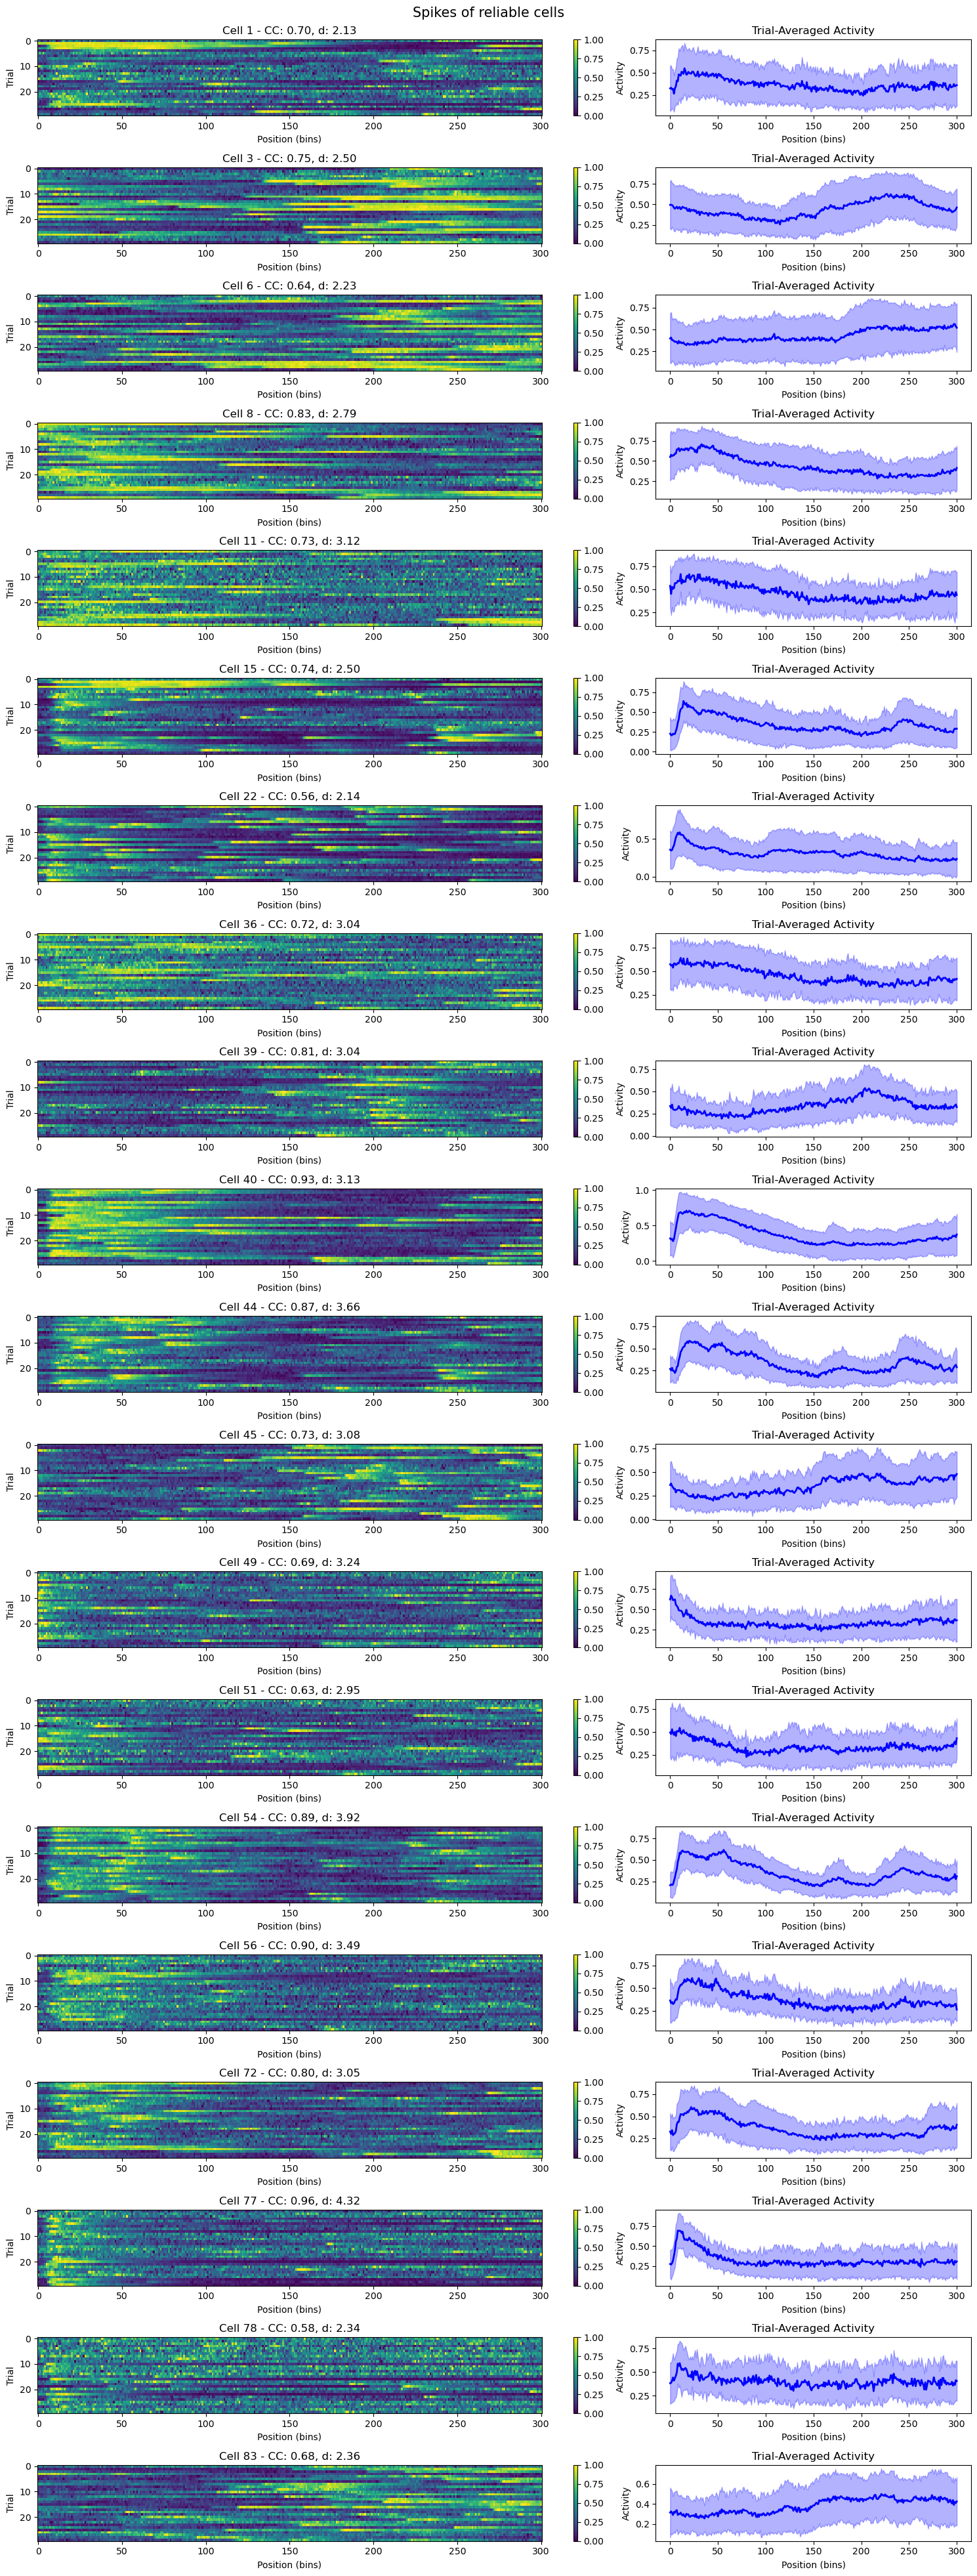

In [107]:
fig2 = plot_reliable_cells_side_by_side(
    normalized_spatial_activity,
    reliable_cells,
    max_cells=20,                # Show up to 10 reliable cells
    avg_cc=avg_cc,               # Optional correlation coefficients
    cohen_d=cohens_d,            # Optional Cohen's D values
    normalize=False               # Apply normalization
)
plt.suptitle('Spikes of reliable cells', fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.985])  # Adjust the rect parameter to add space at the top
plt.show()


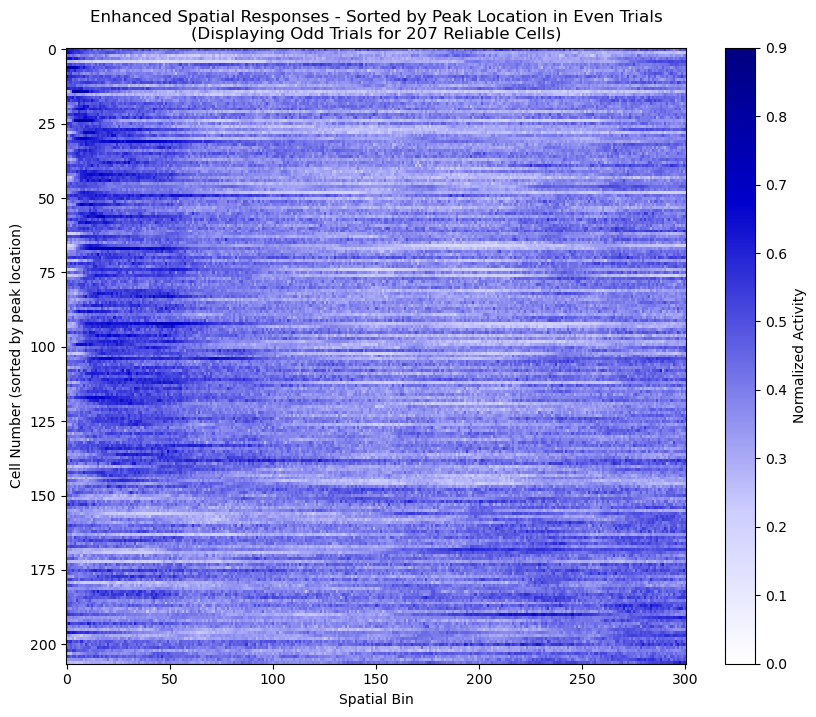

In [110]:
fig1, sorted_indices = create_response_plot(normalized_spatial_activity, reliable_cells, clim=(0, 0.9))  # Optional: manually set contrast limits for stronger effect
# draw a vertical line on a plot

# # For waterfall visualization (alternative approach):
# fig2 = RV.create_waterfall_plot(
#     normalized_spatial_activity,
#     reliable_cells
# )

plt.show()